# Import Libraries

In [3]:
# Data handling
import pandas as pd

# Model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

#encoding
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Evaluation
from sklearn.metrics import r2_score

# Save model
import joblib

#graph
import matplotlib.pyplot as plt

# Load Data

In [4]:
data = pd.read_csv("KnWcGg.csv")

# Data preview
data.head()

,Hours_Studied,Sleep_Hours,Internet_Usage,Gender,Study_Method,Attendance,Final_Score
0,2.0,6.0,3.0,Male,Self Study,75.0,55.0
1,3.0,7.0,2.0,Female,Coaching,80.0,60.0
2,4.0,6.0,4.0,male,Self study,78.0,62.0
3,5.0,8.0,3.0,Femle,Group Study,85.0,70.0
4,6.0,7.0,5.0,Male,Self Study,88.0,72.0


# DATA CLEANING

In [5]:
#Missing Values Handle
data.fillna(data.median(numeric_only=True), inplace=True)

In [6]:
# Remove duplicates
data.drop_duplicates(inplace=True)
print("Shape after cleaning:", data.shape)

Shape after cleaning: (32, 7)


# ENCODING

In [7]:
le = LabelEncoder()

for col in data.select_dtypes(include="object").columns:
    data[col] = le.fit_transform(data[col])

# FEATURES & TARGET

In [8]:
X = data[["Internet_Usage"]]   # input feature
y = data["Final_Score"]       # target/output

# TRAIN-TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(25, 1)
(7, 1)


# FEATURE SCALING

In [10]:
scale = StandardScaler()

X_train_scale = scale.fit_transform(X_train)
X_test_scale = scale.transform(X_test)

# MODEL TRAINING

In [11]:
model = LinearRegression()

model.fit(X_train_scale, y_train)

LinearRegression()

# PREDICTION

In [12]:
y_pred = model.predict(X_test_scale)

# MODEL DETAILS

In [13]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [-7.51542414]
Intercept: 70.44


# EVALUATION

In [14]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6915308173913042


# Graph

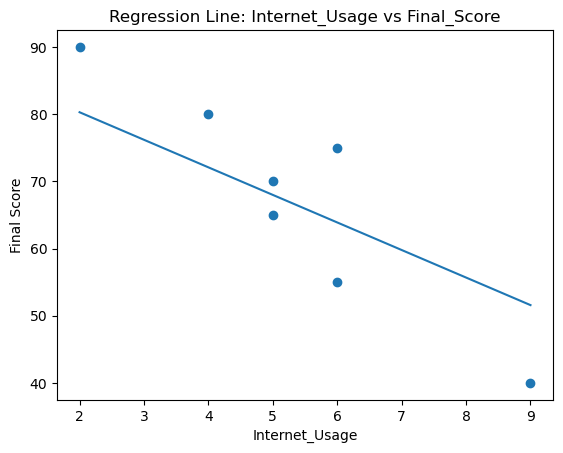

In [15]:
# Scatter plot (actual data)
plt.scatter(X_test, y_test)

# Sort for smooth line
sorted_idx = X_test["Internet_Usage"].argsort()
X_sorted = X_test.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

# Line plot (prediction)
plt.plot(X_sorted, y_pred_sorted)

# Labels
plt.xlabel("Internet_Usage")
plt.ylabel("Final Score")
plt.title("Regression Line: Internet_Usage vs Final_Score")

plt.show()

# SAVE MODEL

In [16]:
joblib.dump(model, "Internet_Usage_vs_final_score")


['Internet_Usage_vs_final_score']